# Step 5. 변수-타깃 관계 분석

- **v2**: 타깃 `mdd_low`(KRX 정규장 저가 기준, 보조: `mdd_close`). 분석 표본 2024-04-01 ~ 2026-06-23(타깃 있는 날), 거래정지 관련 쌍 제외
- **부호 읽는 법**: MDD_5는 음수일수록 위험하다. **IC < 0이면 변수 값이 클수록 더 크게 빠진다(위험 증가)**, IC > 0이면 덜 빠진다.
- 세 관점 (eda_plan 4절):
  1. **횡단면(주 관점)**: 종목 변수의 날짜별 Spearman IC
  2. **시장 시계열**: 날짜별 평균 MDD_5와 시장 공통 변수의 시계열 상관
  3. **패널**: (날짜, 종목) 전체 풀링 상관. 1·2와 방향이 다르면 이유를 본다
- 겹치는 타깃 구간 때문에 유의성은 **5거래일 간격의 겹치지 않는 표본**의 t값(또는 p값)으로 판단한다.
- 전·후반 경계: 표본 거래일의 중앙(2025-05-15). 후반에는 2026년 상반기 고변동 국면이 들어 있다.
- 날짜별 순위 버전(`_rk`) 변수는 Spearman IC가 원 변수와 같으므로 따로 평가하지 않는다.

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

ROOT = Path.cwd().resolve()
while not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from src.evaluate import daily_ic, ic_summary, decile_means, shape_of, ts_corr
from src import features as F
from src import plotting as P

warnings.filterwarnings("ignore")
pd.set_option("display.width", 220)
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_colwidth", 60)
P.setup()

TARGET = "mdd_low"
spec = pd.read_parquet(ROOT / "data" / "cache" / "feature_spec.parquet")   # Step 4 명세(IC 등 채우기 전)
feat = pd.read_parquet(ROOT / "data" / "cache" / "features_train.parquet")
tg = pd.read_parquet(ROOT / "data" / "cache" / "target_train.parquet")
d = feat.merge(tg.loc[tg.use, ["symbol", "trade_date", "mdd_low", "mdd_close", "v1_low_clean"]],
               on=["symbol", "trade_date"]).dropna(subset=[TARGET])   # use: 타깃 있음, 거래정지 관련 쌍 제외
STOCK = spec.loc[spec["단위"] == "종목", "변수명"].tolist()
MARKET = spec.loc[spec["단위"] == "날짜 공통", "변수명"].tolist()
FAMILY = spec.set_index("변수명")["계열"]
days = pd.DatetimeIndex(sorted(d.trade_date.unique()))
NONOVER = days[::5]
SPLIT = days[len(days) // 2]
print(f"표본 {len(d):,}쌍, {len(days)}거래일 ({days.min().date()} ~ {days.max().date()}), 겹치지 않는 표본 {len(NONOVER)}일, 전·후반 경계 {SPLIT.date()}")
print(f"종목 변수 {len(STOCK)}개, 시장 변수 {len(MARKET)}개")

표본 107,880쌍, 540거래일 (2024-04-01 ~ 2026-06-23), 겹치지 않는 표본 108일, 전·후반 경계 2025-05-15
종목 변수 102개, 시장 변수 31개


## 1. 횡단면 IC (종목 변수)

In [2]:
ic = daily_ic(d, STOCK, TARGET)
S = ic_summary(ic, NONOVER, SPLIT)
S["family"] = FAMILY.reindex(S.index)
S = S.sort_values("ic_ir")
S.round(3)

,mean_ic,ic_std,ic_ir,pos_share,month_sign_consistency,t_nonoverlap,ic_first,ic_second,n_days,family
gk_5,-0.326,0.157,-2.074,0.028,1.000,-21.204,-0.332,-0.320,540,변동성
range_5,-0.327,0.160,-2.048,0.031,1.000,-20.784,-0.333,-0.321,540,캔들
parkinson_5,-0.321,0.157,-2.045,0.030,1.000,-20.754,-0.327,-0.316,540,변동성
gk_20,-0.336,0.173,-1.943,0.037,1.000,-19.570,-0.347,-0.325,540,변동성
parkinson_20,-0.335,0.173,-1.932,0.033,1.000,-19.455,-0.347,-0.322,540,변동성
range_1,-0.273,0.142,-1.915,0.037,1.000,-20.186,-0.272,-0.273,540,캔들
range_20,-0.339,0.177,-1.913,0.039,1.000,-19.230,-0.352,-0.327,540,캔들
idio_vol_60,-0.309,0.172,-1.796,0.052,1.000,-17.908,-0.322,-0.295,540,시장 대비
vol_20,-0.305,0.180,-1.699,0.044,1.000,-17.273,-0.322,-0.288,540,변동성
vol_5,-0.244,0.150,-1.621,0.056,1.000,-17.378,-0.250,-0.237,540,변동성


### 1.1 변동성을 통제한 부분 IC

많은 변수가 변동성과 얽혀 있다. 날짜별로 변수 순위를 `vol_20` 순위에 회귀한 잔차로 IC를 다시 구한다. 이 값이 크게 남으면 변동성 외의 정보를 담고 있다는 뜻이다.

In [3]:
def partial_ic(df, feats, ctrl, target):
    g = df.groupby("trade_date")
    z = g[ctrl].rank(pct=True)
    out = {}
    for f in feats:
        if f == ctrl:
            continue
        ok = df[f].notna() & z.notna()
        x = df[f].where(ok).groupby(df.trade_date).rank(pct=True)
        zz = z.where(ok)
        xm = x - x.groupby(df.trade_date).transform("mean")
        zm = zz - zz.groupby(df.trade_date).transform("mean")
        beta = (xm * zm).groupby(df.trade_date).transform("sum") / (zm ** 2).groupby(df.trade_date).transform("sum")
        out[f"{f}"] = xm - beta * zm
    r = pd.DataFrame(out).assign(trade_date=df.trade_date.values, **{target: df[target].values})
    return daily_ic(r, [k for k in out], target)

pic = partial_ic(d, STOCK, "vol_20", TARGET)
PS = ic_summary(pic, NONOVER, SPLIT)[["mean_ic", "ic_ir", "t_nonoverlap"]].add_prefix("partial_")
S = S.join(PS)
S[["mean_ic", "ic_ir", "partial_mean_ic", "partial_ic_ir", "partial_t_nonoverlap"]].sort_values("partial_ic_ir").round(3)

,mean_ic,ic_ir,partial_mean_ic,partial_ic_ir,partial_t_nonoverlap
range_20,-0.339,-1.913,-0.165,-1.631,-17.226
gk_5,-0.326,-2.074,-0.160,-1.625,-17.358
gk_20,-0.336,-1.943,-0.158,-1.606,-16.711
range_5,-0.327,-2.048,-0.158,-1.601,-16.169
parkinson_20,-0.335,-1.932,-0.153,-1.580,-16.224
parkinson_5,-0.321,-2.045,-0.151,-1.527,-15.514
range_1,-0.273,-1.915,-0.128,-1.229,-14.470
idio_vol_60,-0.309,-1.796,-0.127,-1.162,-11.156
vol_60,-0.312,-1.521,-0.124,-0.866,-9.153
dist_low_60,-0.254,-1.573,-0.115,-0.817,-8.709


### 1.2 강건성 점검

In [4]:
rob = pd.DataFrame(index=STOCK)
# (a) 종가 기준 타깃
rob["ic_mdd_close"] = daily_ic(d, STOCK, "mdd_close").mean()
# (b) v1 타깃(기존 일봉, 보정 저가)
rob["ic_v1_target"] = daily_ic(d.dropna(subset=["v1_low_clean"]), STOCK, "v1_low_clean").mean()
# (c) 수급 변수: 늦은 갱신 행 제외
flow_cols = [k for k in STOCK if FAMILY.get(k) in ("수급", "공매도·대차", "신용")]
rob.loc[flow_cols, "ic_excl_late"] = daily_ic(d[~d.late_update_20], flow_cols, TARGET).mean()
# (d) 공매도: 재개 이후(2025-03-31~)만, 대차: 재갱신 이후(2024-08-08~)만
short_cols = [k for k in STOCK if k.startswith("short_")]
lend_cols = [k for k in STOCK if k.startswith("lend_")]
rob.loc[short_cols, "ic_regime"] = daily_ic(d[d.trade_date >= "2025-03-31"], short_cols, TARGET).mean()
rob.loc[lend_cols, "ic_regime"] = daily_ic(d[d.trade_date >= "2024-08-08"], lend_cols, TARGET).mean()
# (e) 2026년 상반기 고변동 국면 제외
rob["ic_excl_2026h1"] = ic[ic.index < "2026-01-01"].mean()
rob.insert(0, "mean_ic", S["mean_ic"])
flip = rob.drop(columns="mean_ic").apply(lambda col: (np.sign(col) != np.sign(rob["mean_ic"])) & col.notna() & (rob["mean_ic"].abs() > 0.03))
print("부호가 뒤집힌 경우 (|IC| > 0.03인 변수):", {c: rob.index[flip[c]].tolist() for c in flip.columns if flip[c].any()} or "없음")
rob.reindex(S.index).round(3)

부호가 뒤집힌 경우 (|IC| > 0.03인 변수): 없음


,mean_ic,ic_mdd_close,ic_v1_target,ic_excl_late,ic_regime,ic_excl_2026h1
gk_5,-0.326,-0.202,-0.334,NaN,NaN,-0.329
range_5,-0.327,-0.204,-0.336,NaN,NaN,-0.329
parkinson_5,-0.321,-0.201,-0.330,NaN,NaN,-0.323
gk_20,-0.336,-0.210,-0.342,NaN,NaN,-0.340
parkinson_20,-0.335,-0.211,-0.341,NaN,NaN,-0.338
range_1,-0.273,-0.168,-0.282,NaN,NaN,-0.274
range_20,-0.339,-0.213,-0.346,NaN,NaN,-0.344
idio_vol_60,-0.309,-0.198,-0.312,NaN,NaN,-0.310
vol_20,-0.305,-0.196,-0.313,NaN,NaN,-0.309
vol_5,-0.244,-0.154,-0.252,NaN,NaN,-0.245


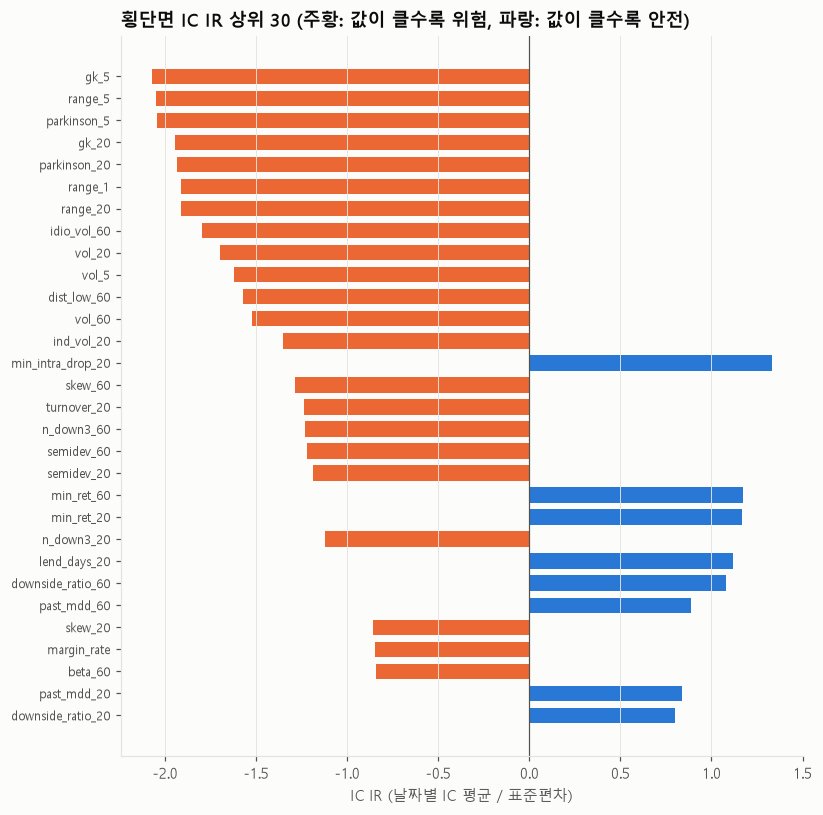

In [5]:
top = S.reindex(S.ic_ir.abs().sort_values(ascending=False).index).head(30)
fig, ax = plt.subplots(figsize=(8, 8.5))
colors = np.where(top.ic_ir < 0, P.SERIES[1], P.SERIES[0])
ax.barh(range(len(top))[::-1], top.ic_ir, color=colors, height=0.7)
ax.set_yticks(range(len(top))[::-1], top.index, fontsize=8)
ax.axvline(0, color=P.TEXT_2, lw=0.8)
ax.set_xlabel("IC IR (날짜별 IC 평균 / 표준편차)")
ax.set_title("횡단면 IC IR 상위 30 (주황: 값이 클수록 위험, 파랑: 값이 클수록 안전)")
ax.grid(axis="y", visible=False)
P.save(fig, "06_ic_ir_top30")
plt.show()

## 2. 분위별 타깃 평균 (단조성·비선형성)

In [6]:
dec = {f: decile_means(d, f, TARGET) for f in STOCK}
shape = pd.Series({f: shape_of(v) for f, v in dec.items()}, name="shape")
spread = pd.Series({f: v.iloc[-1] - v.iloc[0] for f, v in dec.items()}, name="d10_minus_d1")
S = S.join(shape).join(spread)
display(S["shape"].value_counts().to_frame("변수 수"))
S.loc[~S["shape"].str.startswith("단조"), ["mean_ic", "ic_ir", "shape", "d10_minus_d1"]].round(4)

,변수 수
shape,
단조 감소,31
U자(양 끝이 위험),23
역U자(양 끝이 안전),19
비단조·약함,15
단조 증가,14


,mean_ic,ic_ir,shape,d10_minus_d1
ma_gap_60,-0.1355,-0.7177,U자(양 끝이 위험),-0.0164
ret_60,-0.1360,-0.7140,비단조·약함,-0.0170
pension_net_20,-0.0821,-0.7088,비단조·약함,-0.0080
pension_net_5,-0.0716,-0.6305,역U자(양 끝이 안전),-0.0061
excess_ret_20,-0.1117,-0.6117,U자(양 끝이 위험),-0.0146
ret_20,-0.1117,-0.6117,U자(양 끝이 위험),-0.0146
inst_net_20,-0.0758,-0.6101,비단조·약함,-0.0071
ma_gap_20,-0.1058,-0.5850,U자(양 끝이 위험),-0.0134
prog_nonarb_net_20,-0.0591,-0.5524,역U자(양 끝이 안전),-0.0048
inst_net_5,-0.0669,-0.5487,비단조·약함,-0.0068


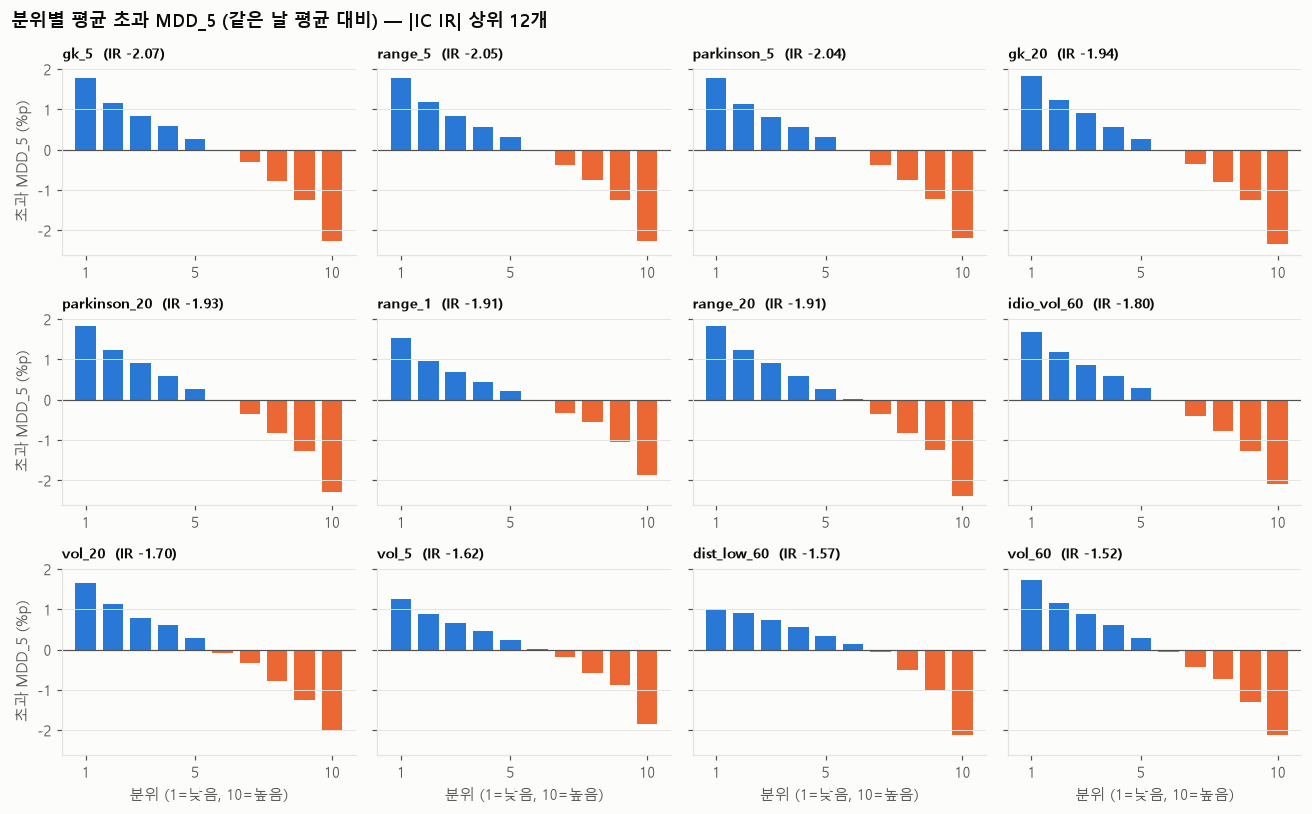

In [7]:
pick = S.ic_ir.abs().sort_values(ascending=False).index[:12]
fig, axes = plt.subplots(3, 4, figsize=(12, 7.5), sharey=True)
for ax, f in zip(axes.ravel(), pick):
    v = dec[f]
    ax.bar(v.index, v.values * 100, color=np.where(v.values < 0, P.SERIES[1], P.SERIES[0]), width=0.75)
    ax.axhline(0, color=P.TEXT_2, lw=0.8)
    ax.set_title(f"{f}  (IR {S.loc[f, 'ic_ir']:.2f})", fontsize=9)
    ax.set_xticks([1, 5, 10])
    ax.grid(axis="x", visible=False)
for ax in axes[:, 0]:
    ax.set_ylabel("초과 MDD_5 (%p)")
for ax in axes[-1]:
    ax.set_xlabel("분위 (1=낮음, 10=높음)")
fig.suptitle("분위별 평균 초과 MDD_5 (같은 날 평균 대비) — |IC IR| 상위 12개", x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout()
P.save(fig, "06_deciles_top12")
plt.show()

## 3. 시장 시계열 (시장 공통 변수)

In [8]:
daily = d.groupby("trade_date")[TARGET].mean()
mk = feat.drop_duplicates("trade_date").set_index("trade_date")[MARKET]
TS = pd.DataFrame({f: ts_corr(daily, mk[f], NONOVER, SPLIT) for f in MARKET}).T
TS["family"] = FAMILY.reindex(TS.index)
TS = TS.sort_values("ts_rho_nonoverlap")
TS.round(3)

,ts_rho,ts_rho_nonoverlap,p_nonoverlap,n_nonoverlap,ts_first,ts_second,family
cs_dispersion_1,-0.189,-0.217,0.024,108.0,-0.034,-0.335,시장
mkt_ret_20,-0.230,-0.192,0.046,108.0,-0.193,-0.390,시장
mkt_institution_net_20,-0.094,-0.184,0.057,108.0,-0.161,-0.023,시장 수급
mkt_ret_60,-0.213,-0.179,0.064,108.0,-0.122,-0.542,시장
cs_dispersion_5,-0.173,-0.175,0.070,108.0,0.005,-0.344,시장
mkt_individual_net_5,-0.127,-0.166,0.085,108.0,0.004,-0.245,시장 수급
mkt_ma_gap_20,-0.164,-0.107,0.272,108.0,-0.061,-0.287,시장
mkt_individual_net_1,-0.079,-0.102,0.293,108.0,-0.017,-0.136,시장 수급
mkt_range_1,-0.141,-0.101,0.297,108.0,-0.111,-0.216,시장
bond3y_chg_20,-0.088,-0.081,0.402,108.0,-0.075,-0.142,시장


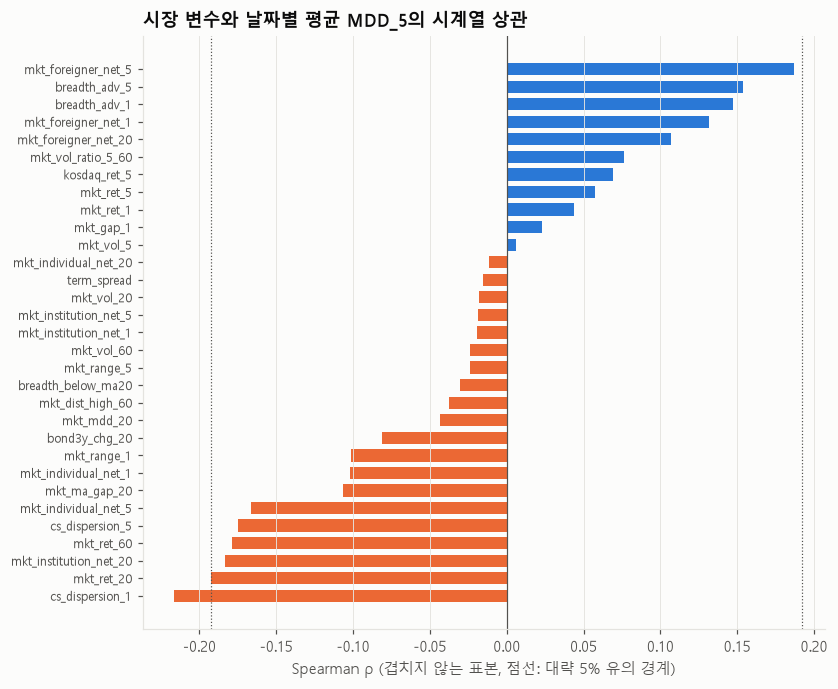

In [9]:
fig, ax = plt.subplots(figsize=(8, 7))
t_ = TS.sort_values("ts_rho_nonoverlap")
ax.barh(range(len(t_)), t_.ts_rho_nonoverlap, color=np.where(t_.ts_rho_nonoverlap < 0, P.SERIES[1], P.SERIES[0]), height=0.7)
ax.set_yticks(range(len(t_)), t_.index, fontsize=8)
ax.axvline(0, color=P.TEXT_2, lw=0.8)
crit = 2 / np.sqrt(len(NONOVER))
for x_ in (-crit, crit):
    ax.axvline(x_, color=P.TEXT_2, lw=0.8, ls=":")
ax.set_xlabel("Spearman ρ (겹치지 않는 표본, 점선: 대략 5% 유의 경계)")
ax.set_title("시장 변수와 날짜별 평균 MDD_5의 시계열 상관")
ax.grid(axis="y", visible=False)
P.save(fig, "06_market_ts")
plt.show()

## 4. 패널 (풀링) 상관과 관점 간 비교

풀링 상관은 '같은 날 종목 간 차이(횡단면)'와 '날짜 간 차이(시장)'가 섞인 값이다. 종목 변수에 대해 날짜 평균끼리의 상관(between)도 함께 구해서, 풀링과 횡단면의 방향이 다르면 어느 쪽 효과 때문인지 본다.

In [10]:
pool = {}
for f in STOCK + MARKET:
    x = d[[f, TARGET]].dropna()
    pool[f] = stats.spearmanr(x[f], x[TARGET])[0]
pool = pd.Series(pool, name="pooled_rho")
dm = d.groupby("trade_date")[STOCK + [TARGET]].mean()
between = pd.Series({f: stats.spearmanr(dm[f], dm[TARGET], nan_policy="omit")[0] for f in STOCK}, name="between_rho")
S = S.join(pool).join(between)
TS = TS.join(pool)
dis = S[(np.sign(S.pooled_rho) != np.sign(S.mean_ic)) & ((S.mean_ic.abs() > 0.03) | (S.pooled_rho.abs() > 0.03))]
print(f"횡단면 IC와 풀링 상관의 부호가 다른 종목 변수: {len(dis)}개")
dis[["mean_ic", "pooled_rho", "between_rho", "family"]].round(3)

횡단면 IC와 풀링 상관의 부호가 다른 종목 변수: 4개


,mean_ic,pooled_rho,between_rho,family
excess_ret_5,-0.072,0.005,0.136,시장 대비
ind_ret_5,-0.050,0.004,0.125,업종
prog_arb_net_20,0.036,-0.033,-0.094,수급
short_share_1,0.038,-0.007,-0.019,공매도·대차


In [11]:
mdis = TS[np.sign(TS.pooled_rho) != np.sign(TS.ts_rho)]
print(f"시계열 상관과 풀링 상관의 부호가 다른 시장 변수: {len(mdis)}개")
mdis[["ts_rho", "pooled_rho"]].round(3)

시계열 상관과 풀링 상관의 부호가 다른 시장 변수: 3개


,ts_rho,pooled_rho
mkt_mdd_20,-0.066,0.000
mkt_institution_net_5,0.021,-0.006
mkt_individual_net_20,0.013,-0.016


## 5. 다중공선성과 대표 변수

In [12]:
# 겹치지 않는 날짜에서 종목 변수 간 횡단면 Spearman 평균
sub = d[d.trade_date.isin(NONOVER)]
R = sum(g[STOCK].rank().corr() for _, g in sub.groupby("trade_date")) / sub.trade_date.nunique()
R = R.fillna(0)
dist = 1 - R.abs().values
np.fill_diagonal(dist, 0)
Z = hierarchy.linkage(squareform(dist, checks=False), method="average")
cl = pd.Series(hierarchy.fcluster(Z, t=0.3, criterion="distance"), index=STOCK, name="cluster")   # 평균 |ρ| ≥ 0.7이면 같은 묶음
S = S.join(cl)
rep = S.groupby("cluster").apply(lambda g: g.ic_ir.abs().idxmax()).rename("representative")
S["representative"] = S.cluster.map(rep)
S["is_rep"] = S.index == S.representative
multi = S.groupby("cluster").filter(lambda g: len(g) > 1)
print(f"종목 변수 {len(STOCK)}개 → 묶음 {S.cluster.nunique()}개 (2개 이상인 묶음 {multi.cluster.nunique()}개)")
multi.sort_values(["cluster", "ic_ir"])[["cluster", "representative", "ic_ir", "partial_ic_ir", "family"]].round(3)

종목 변수 102개 → 묶음 62개 (2개 이상인 묶음 20개)


,cluster,representative,ic_ir,partial_ic_ir,family
short_share_5,14,short_share_20,0.590,0.191,공매도·대차
short_share_20,14,short_share_20,0.642,0.069,공매도·대차
volume_z_20,20,volume_z_20,-0.354,-0.453,거래·유동성
value_ratio_1_20,20,volume_z_20,-0.286,-0.577,거래·유동성
turnover_ratio_5_60,21,turnover_ratio_5_60,-0.430,-0.163,거래·유동성
value_ratio_5_20,21,turnover_ratio_5_60,-0.352,-0.491,거래·유동성
semidev_20,24,min_intra_drop_20,-1.186,0.046,하방 특성
n_down3_20,24,min_intra_drop_20,-1.124,-0.023,하방 특성
past_mdd_20,24,min_intra_drop_20,0.836,-0.051,하방 특성
min_ret_20,24,min_intra_drop_20,1.170,-0.195,하방 특성


In [13]:
# 대표 변수끼리의 상관: 0.5 이상인 쌍
reps = S[S.is_rep].index
Rr = R.loc[reps, reps]
pairs = [(a, b, Rr.loc[a, b]) for i, a in enumerate(reps) for b in reps[i + 1:] if abs(Rr.loc[a, b]) >= 0.5]
pd.DataFrame(pairs, columns=["a", "b", "rho"]).sort_values("rho", key=abs, ascending=False).round(3).head(20)

,a,b,rho
0,gk_5,range_1,0.721
16,turnover_20,lend_days_20,-0.700
1,gk_5,vol_5,0.696
33,excess_ret_5,past_mdd_5,0.688
20,skew_20,downside_ratio_20,-0.682
26,pos_20,downside_ratio_20,-0.674
8,vol_5,vol_ratio_5_20,0.664
18,n_down3_60,past_mdd_60,-0.663
24,pos_20,excess_ret_5,0.656
34,pension_net_1,inst_net_1,0.655


In [14]:
# 시장 변수: 시계열 Spearman으로 묶기
Rm = mk.loc[days, MARKET].rank().corr().fillna(0)
distm = 1 - Rm.abs().values
np.fill_diagonal(distm, 0)
clm = pd.Series(hierarchy.fcluster(hierarchy.linkage(squareform(distm, checks=False), "average"), t=0.3, criterion="distance"),
                index=MARKET, name="cluster")
TS = TS.join(clm)
repm = TS.groupby("cluster").apply(lambda g: g.ts_rho_nonoverlap.abs().idxmax()).rename("representative")
TS["representative"] = TS.cluster.map(repm)
TS["is_rep"] = TS.index == TS.representative
print(f"시장 변수 {len(MARKET)}개 → 묶음 {TS.cluster.nunique()}개")
TS.sort_values(["cluster", "ts_rho_nonoverlap"])[["cluster", "representative", "ts_rho_nonoverlap", "ts_first", "ts_second"]].round(3)

시장 변수 31개 → 묶음 20개


,cluster,representative,ts_rho_nonoverlap,ts_first,ts_second
mkt_institution_net_1,1,mkt_institution_net_1,-0.019,-0.030,0.007
mkt_institution_net_5,2,mkt_institution_net_5,-0.019,-0.021,0.049
mkt_institution_net_20,3,mkt_institution_net_20,-0.184,-0.161,-0.023
mkt_range_1,4,mkt_range_1,-0.101,-0.111,-0.216
mkt_range_5,4,mkt_range_1,-0.024,0.105,-0.261
cs_dispersion_1,5,cs_dispersion_1,-0.217,-0.034,-0.335
cs_dispersion_5,5,cs_dispersion_1,-0.175,0.005,-0.344
mkt_ret_60,6,mkt_ret_60,-0.179,-0.122,-0.542
term_spread,7,term_spread,-0.015,0.083,0.012
bond3y_chg_20,8,bond3y_chg_20,-0.081,-0.075,-0.142


## 6. 안정성 (전반 vs 후반)

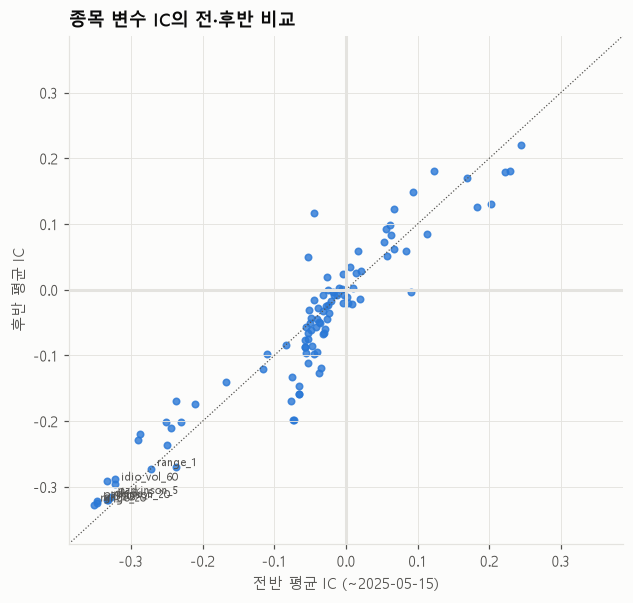

전·후반 부호 일치: 91 / 102. |IC| ≥ 0.05인 변수 중 부호가 다른 것: []
전·후반 IC 상관: 0.941


In [15]:
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(S.ic_first, S.ic_second, s=18, color=P.SERIES[0], alpha=0.8)
lim = max(S[["ic_first", "ic_second"]].abs().max()) * 1.1
ax.plot([-lim, lim], [-lim, lim], color=P.TEXT_2, lw=0.8, ls=":")
ax.axhline(0, color=P.GRID)
ax.axvline(0, color=P.GRID)
for f in S.ic_ir.abs().sort_values(ascending=False).index[:8]:
    ax.annotate(f, (S.loc[f, "ic_first"], S.loc[f, "ic_second"]), fontsize=7, color=P.TEXT_2,
                xytext=(4, 2), textcoords="offset points")
ax.set_xlabel(f"전반 평균 IC (~{SPLIT.date()})")
ax.set_ylabel("후반 평균 IC")
ax.set_title("종목 변수 IC의 전·후반 비교")
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
P.save(fig, "06_ic_halves")
plt.show()
same = (np.sign(S.ic_first) == np.sign(S.ic_second))
print(f"전·후반 부호 일치: {same.sum()} / {len(S)}. |IC| ≥ 0.05인 변수 중 부호가 다른 것:",
      S[~same & (S.mean_ic.abs() >= 0.05)].index.tolist())
print("전·후반 IC 상관:", round(S[["ic_first", "ic_second"]].corr().iloc[0, 1], 3))

## 7. 추천 등급

**종목 변수**
- **강력 추천**: 묶음 대표이고, |IC IR| ≥ 0.5, 겹치지 않는 표본 |t| ≥ 4, 월별 부호 일치 ≥ 80%, 전·후반 부호가 같음
- **검토**: |IC IR| ≥ 0.2, |t| ≥ 2, 전·후반 부호가 같음. 강력 추천 기준을 넘지만 대표가 아닌 변수(중복)도 여기에 둔다
- **제외**: 그 외

**시장 변수**(날짜 수가 적어 근거가 약하다)
- **강력 추천**: 묶음 대표, 겹치지 않는 표본 |ρ| ≥ 0.3이고 p < 0.01, 전·후반 부호가 같음
- **검토**: |ρ| ≥ 0.15, 전·후반 부호가 같음
- **제외**: 그 외

In [16]:
def grade_stock(r):
    strong = abs(r.ic_ir) >= 0.5 and abs(r.t_nonoverlap) >= 4 and r.month_sign_consistency >= 0.8 and np.sign(r.ic_first) == np.sign(r.ic_second)
    if strong and r.is_rep:
        return "강력 추천"
    if strong or (abs(r.ic_ir) >= 0.2 and abs(r.t_nonoverlap) >= 2 and np.sign(r.ic_first) == np.sign(r.ic_second)):
        return "검토"
    return "제외"

def grade_market(r):
    same = np.sign(r.ts_first) == np.sign(r.ts_second)
    if r.is_rep and abs(r.ts_rho_nonoverlap) >= 0.3 and r.p_nonoverlap < 0.01 and same:
        return "강력 추천"
    if abs(r.ts_rho_nonoverlap) >= 0.15 and same:
        return "검토"
    return "제외"

S["grade"] = S.apply(grade_stock, axis=1)
TS["grade"] = TS.apply(grade_market, axis=1)
print("종목 변수:", S.grade.value_counts().to_dict(), "| 시장 변수:", TS.grade.value_counts().to_dict())
S[S.grade == "강력 추천"].sort_values("ic_ir", key=abs, ascending=False)[
    ["family", "mean_ic", "ic_ir", "t_nonoverlap", "partial_ic_ir", "month_sign_consistency", "ic_first", "ic_second", "shape"]].round(3)

종목 변수: {'검토': 54, '강력 추천': 25, '제외': 23} | 시장 변수: {'제외': 26, '검토': 5}


,family,mean_ic,ic_ir,t_nonoverlap,partial_ic_ir,month_sign_consistency,ic_first,ic_second,shape
gk_5,변동성,-0.326,-2.074,-21.204,-1.625,1.000,-0.332,-0.320,단조 감소
range_1,캔들,-0.273,-1.915,-20.186,-1.229,1.000,-0.272,-0.273,단조 감소
vol_5,변동성,-0.244,-1.621,-17.378,-0.755,1.000,-0.250,-0.237,단조 감소
dist_low_60,가격 위치,-0.254,-1.573,-15.471,-0.817,1.000,-0.237,-0.270,단조 감소
ind_vol_20,업종,-0.227,-1.353,-13.640,-0.444,1.000,-0.243,-0.211,단조 감소
min_intra_drop_20,하방 특성,0.232,1.331,13.663,0.119,1.000,0.244,0.221,단조 증가
skew_60,하방 특성,-0.118,-1.285,-12.075,-0.572,1.000,-0.116,-0.121,단조 감소
turnover_20,거래·유동성,-0.216,-1.237,-11.192,-0.385,1.000,-0.230,-0.202,단조 감소
n_down3_60,하방 특성,-0.254,-1.235,-12.790,-0.496,1.000,-0.287,-0.220,단조 감소
lend_days_20,공매도·대차,0.170,1.119,10.341,0.222,1.000,0.169,0.170,단조 증가


In [17]:
TS[TS.grade != "제외"].sort_values("ts_rho_nonoverlap", key=abs, ascending=False)[
    ["family", "ts_rho", "ts_rho_nonoverlap", "p_nonoverlap", "ts_first", "ts_second", "grade"]].round(3)

,family,ts_rho,ts_rho_nonoverlap,p_nonoverlap,ts_first,ts_second,grade
cs_dispersion_1,시장,-0.189,-0.217,0.024,-0.034,-0.335,검토
mkt_ret_20,시장,-0.230,-0.192,0.046,-0.193,-0.390,검토
mkt_institution_net_20,시장 수급,-0.094,-0.184,0.057,-0.161,-0.023,검토
mkt_ret_60,시장,-0.213,-0.179,0.064,-0.122,-0.542,검토
breadth_adv_5,시장,0.151,0.154,0.112,0.200,0.113,검토


## 7.1 v1(기존 일봉) 평가와 비교

In [18]:
V1 = pd.read_parquet(ROOT / "data" / "cache" / "step5_stock_eval_v1.parquet")
cmp_ = S[["ic_ir", "grade", "partial_ic_ir"]].join(V1[["ic_ir", "grade", "partial_ic_ir"]], rsuffix="_v1", how="left")
cmp_["d_ir"] = cmp_.ic_ir - cmp_.ic_ir_v1
print("IC IR 상관(v2 vs v1):", round(cmp_[["ic_ir", "ic_ir_v1"]].corr().iloc[0, 1], 4))
print("등급 변화:"); display(pd.crosstab(cmp_.grade_v1.fillna("(v2 신규)"), cmp_.grade, margins=True))
print("|IC IR| 변화가 큰 변수(상위 15):")
cmp_.reindex(cmp_.d_ir.abs().sort_values(ascending=False).index).head(15).round(3)

IC IR 상관(v2 vs v1): 0.9959
등급 변화:


grade,강력 추천,검토,제외,All
grade_v1,,,,
(v2 신규),1,1,1,3
강력 추천,23,2,0,25
검토,1,46,2,49
제외,0,5,20,25
All,25,54,23,102


|IC IR| 변화가 큰 변수(상위 15):


,ic_ir,grade,partial_ic_ir,ic_ir_v1,grade_v1,partial_ic_ir_v1,d_ir
lower_shadow_5,0.020,제외,-0.190,0.371,검토,-0.047,-0.350
zero_vol_20,-0.259,검토,0.532,0.091,제외,0.138,-0.350
lower_shadow_1,-0.162,제외,-0.261,0.087,제외,-0.096,-0.248
upper_shadow_5,0.086,제외,0.053,-0.078,제외,-0.063,0.165
skew_60,-1.285,강력 추천,-0.572,-1.128,강력 추천,-0.454,-0.157
short_share_1,0.316,검토,0.039,0.453,검토,0.140,-0.137
skew_20,-0.858,강력 추천,-0.310,-0.733,강력 추천,-0.272,-0.125
short_share_5,0.590,검토,0.191,0.697,검토,0.263,-0.108
upper_shadow_1,0.161,제외,0.201,0.059,제외,0.100,0.102
vol_ratio_5_20,-0.302,검토,-0.488,-0.403,검토,-0.598,0.100


## 8. `feature_candidates.csv` 갱신

In [19]:
def note_stock(f, r):
    n = []
    if not r.is_rep:
        n.append(f"대표: {r.representative}")
    n.append(f"변동성 통제 IR {r.partial_ic_ir:.2f}" if pd.notna(r.partial_ic_ir) else "")
    n.append(f"모양: {r['shape']}")
    if np.sign(r.pooled_rho) != np.sign(r.mean_ic) and abs(r.mean_ic) > 0.03:
        n.append(f"풀링 부호 반대(between {r.between_rho:.2f})")
    return "; ".join(x for x in n if x)

def note_market(f, r):
    n = ["시계열 평가(IC 칸 = 겹치지 않는 표본 Spearman ρ, IR 칸 비움)", f"p={r.p_nonoverlap:.3f}"]
    if not r.is_rep:
        n.append(f"대표: {r.representative}")
    return "; ".join(n)

cand = spec.set_index("변수명")
for f, r in S.iterrows():
    cand.loc[f, "평균 IC"] = round(r.mean_ic, 4)
    cand.loc[f, "IC IR"] = round(r.ic_ir, 3)
    cand.loc[f, "안정성"] = f"전반 {r.ic_first:.3f} / 후반 {r.ic_second:.3f}, 월 부호 일치 {r.month_sign_consistency:.0%}, t={r.t_nonoverlap:.1f}"
    cand.loc[f, "추천 등급"] = r.grade
    base = spec.set_index("변수명").loc[f, "비고"]
    cand.loc[f, "비고"] = "; ".join(x for x in [base if isinstance(base, str) else "", note_stock(f, r)] if x)
for f, r in TS.iterrows():
    cand.loc[f, "평균 IC"] = round(r.ts_rho_nonoverlap, 4)
    cand.loc[f, "IC IR"] = np.nan
    cand.loc[f, "안정성"] = f"전반 {r.ts_first:.3f} / 후반 {r.ts_second:.3f}"
    cand.loc[f, "추천 등급"] = r.grade
    base = spec.set_index("변수명").loc[f, "비고"]
    cand.loc[f, "비고"] = "; ".join(x for x in [base if isinstance(base, str) else "", note_market(f, r)] if x)
cand = cand.reset_index()
cand.to_csv(ROOT / "outputs" / "feature_candidates.csv", index=False, encoding="utf-8-sig")
S.to_parquet(ROOT / "data" / "cache" / "step5_stock_eval.parquet")
TS.to_parquet(ROOT / "data" / "cache" / "step5_market_eval.parquet")
print(cand["추천 등급"].value_counts().to_dict())
cand[cand["추천 등급"] == "강력 추천"][["변수명", "계열", "평균 IC", "IC IR", "안정성"]]

{'검토': 59, '제외': 49, '강력 추천': 25}


,변수명,계열,평균 IC,IC IR,안정성
8,vol_5,변동성,-0.2437,-1.621,"전반 -0.250 / 후반 -0.237, 월 부호 일치 100%, t=-17.4"
12,gk_5,변동성,-0.3257,-2.074,"전반 -0.332 / 후반 -0.320, 월 부호 일치 100%, t=-21.2"
19,downside_ratio_20,하방 특성,0.1211,0.799,"전반 0.094 / 후반 0.148, 월 부호 일치 89%, t=8.4"
20,skew_20,하방 특성,-0.0841,-0.858,"전반 -0.083 / 후반 -0.085, 월 부호 일치 96%, t=-8.3"
26,skew_60,하방 특성,-0.1182,-1.285,"전반 -0.116 / 후반 -0.121, 월 부호 일치 100%, t=-12.1"
29,n_down3_60,하방 특성,-0.2536,-1.235,"전반 -0.287 / 후반 -0.220, 월 부호 일치 100%, t=-12.8"
30,past_mdd_5,하방 특성,0.0990,0.624,"전반 0.113 / 후반 0.085, 월 부호 일치 96%, t=6.5"
32,past_mdd_60,하방 특성,0.1668,0.889,"전반 0.203 / 후반 0.131, 월 부호 일치 100%, t=9.3"
33,min_intra_drop_20,하방 특성,0.2324,1.331,"전반 0.244 / 후반 0.221, 월 부호 일치 100%, t=13.7"
36,dist_low_60,가격 위치,-0.2535,-1.573,"전반 -0.237 / 후반 -0.270, 월 부호 일치 100%, t=-15.5"


## 9. 요약 (v2)

- **표본**: 107,880쌍, 540거래일. 타깃은 `mdd_low`(KRX 정규장 저가)이고, 거래정지 관련 쌍은 뺐다.
- **등급**: 종목 변수 102개 중 강력 추천 25, 검토 54, 제외 23이다. 시장 변수 31개는 검토 5, 제외 26이다.
- **v1과 비교**
  - 변수별 IC IR 상관이 0.996으로 결론이 거의 같다.
  - v1의 강력 추천 25개 중 23개가 그대로 남았다.
  - 강력 추천에서 검토로 내려간 것은 `idio_vol_60`과 `vol_ratio_20_60`이다. `idio_vol_60`은 IR이 -1.80으로 여전히 강하지만, 이번에는 `gk_5`와 같은 묶음으로 분류돼 대표가 아니게 됐다. `vol_ratio_20_60`은 월별 부호 일치율이 기준(80%)에 못 미쳤다.
  - 새로 강력 추천이 된 것은 `turnover_20`(v2 신규, IR -1.24)과 `n_down3_60`이다.
- **새 변수**
  - `turnover_20`(회전율): 회전율이 높을수록 위험하다. 변동성을 통제해도 IR -0.39가 남는다.
  - `log_mcap`(시가총액): 단독으로는 IR -0.04로 약하다. 하지만 변동성을 통제하면 +0.25로, 같은 변동성이면 대형주가 덜 빠진다.
- **강건성**: v1 타깃, 늦은 갱신 행 제외, 공매도 재개 이후만, 2026년 상반기 제외 조건에서 모두 부호가 뒤집힌 변수가 없다. 전·후반 IC 상관은 0.941이다.
- **시장 변수**: 강력 추천은 여전히 없다. 검토 5개는 종목 간 수익률 분산(ρ -0.22), KOSPI 20일 수익률(-0.19), 기관 20일 순매수(-0.18), KOSPI 60일 수익률(-0.18), 상승 종목 비율 5일 평균(+0.15)이다.